In [1]:
############################
# BLOCK 1:  IMPORTS
############################

# libraries!
import numpy as np      # numpy is Python's "array" library
import pandas as pd     # Pandas is Python's "data" library ("dataframe" == spreadsheet)

In [2]:
#############################
# BLOCK 2:  VARIABLES LISTING
#############################

# for reference, as you work throughout, come back and list all the variable names
#   here along with what that variable holds

#   Variable:  Contents
#   -------------------
#   [FILL IN VARS BELOW]
#

In [3]:
####################################
#from sklearn.datasets import load_iris
#data = load_iris()
#df = pd.DataFrame(data.data, columns=data.feature_names)
#df

In [4]:
#############################
# BLOCK 3:  READING DATA
#############################

# let's read in our flower data...
#
filename = 'iris.csv'
df = pd.read_csv(filename, header=0)   # encoding="latin1" et al.
print(f"{filename}: file read into a pandas DataFrame.")
df.head()

iris.csv: file read into a pandas DataFrame.


,sepallen,sepalwid,petallen,petalwid,irisname,junk
0,NaN,3.5,1.4,0.2,setosa,remove_me
1,4.9,3.0,1.4,0.2,setosa,remove_me
2,4.7,3.2,1.3,0.2,setosa,remove_me
3,4.6,3.1,1.5,0.2,setosa,remove_me
4,5.0,3.6,1.4,0.2,setosa,remove_me


In [5]:
#############################
# BLOCK 4:  SETTING OPTIONS
#############################

#
# a dataframe is a "spreadsheet in Python"
#    (this one seems to have an extra column!)
#
pd.set_option('display.max_rows', 8)  # None for no limit; default: 10
pd.set_option('display.min_rows', 8)  # None for no limit; default: 10
# let's view it!
df

,sepallen,sepalwid,petallen,petalwid,irisname,junk
0,NaN,3.5,1.4,0.2,setosa,remove_me
1,4.9,3.0,1.4,0.2,setosa,remove_me
2,4.7,3.2,1.3,0.2,setosa,remove_me
3,4.6,3.1,1.5,0.2,setosa,remove_me
...,...,...,...,...,...,...
146,6.3,2.5,5.0,1.9,virginica,remove_me
147,6.5,3.0,5.2,2.0,virginica,remove_me
148,6.2,3.4,5.4,2.3,alieniris,remove_me
149,5.9,3.0,5.1,1.8,alieniris,remove_me


In [6]:
##############################
# BLOCK 5:  USING DF'S .info()
##############################

#
# let's look at our pandas DataFrame's info   (Aargh: that extra column!)
#
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sepallen  149 non-null    float64
 1   sepalwid  150 non-null    float64
 2   petallen  150 non-null    float64
 3   petalwid  149 non-null    float64
 4   irisname  149 non-null    str    
 5   junk      150 non-null    str    
dtypes: float64(4), str(2)
memory usage: 7.2 KB


In [7]:
#############################
# BLOCK 6:  CLEANING DATA
#############################

#
# let's drop that last column (dropping is usually by _name_):
#
#   if you want a list of the column names use df.columns
#col5name = df.columns[5]  # get column name at index 5

df_clean = df.drop(columns=['junk']) # drop by name is typical, but what else is possible?
df_clean.info()                         # Is the bad last column gone?

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sepallen  149 non-null    float64
 1   sepalwid  150 non-null    float64
 2   petallen  150 non-null    float64
 3   petalwid  149 non-null    float64
 4   irisname  149 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [8]:
##############################
# BLOCK 7:  FEATURE NAMES DICT
##############################

#
# let's keep our column names in variables, for reference;
#   in machine learning contexts, these are referred to as "features"
#
features = df_clean.columns            # "list" of columns
print(f"FEATURES: {features}\n")
  # It's a "pandas" list, called an Index
  # use it just as a Python list of strings:
print(f"First feature: {features[0]}\n")

# let's create a dictionary to look up any column index by name
feature_name_to_index = {}
for i, name in enumerate(features):
    feature_name_to_index[name] = i  # using the name (as key), assign the value (i)
print(f"feature_name_to_index: {feature_name_to_index}")

FEATURES: Index(['sepallen', 'sepalwid', 'petallen', 'petalwid', 'irisname'], dtype='str')

First feature: sepallen

feature_name_to_index: {'sepallen': 0, 'sepalwid': 1, 'petallen': 2, 'petalwid': 3, 'irisname': 4}


In [9]:
##############################
# BLOCK 8:  INSPECTING DATA
##############################

#
# let's look at our cleaned-up dataframe...
#
df_clean.info()
print('=' * 70)

#
# Notice that the non-null count is _different_ for irisname!
# Why?  Show a table and inspect...
print(df_clean)
print('=' * 70)

# or more to the point, grab that column and inspect:
print(f"Irisname entries: {df_clean['irisname'].unique()}")

# also note how the last two rows in the df have problems, among others...


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sepallen  149 non-null    float64
 1   sepalwid  150 non-null    float64
 2   petallen  150 non-null    float64
 3   petalwid  149 non-null    float64
 4   irisname  149 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
     sepallen  sepalwid  petallen  petalwid   irisname
0         NaN       3.5       1.4       0.2     setosa
1         4.9       3.0       1.4       0.2     setosa
2         4.7       3.2       1.3       0.2     setosa
3         4.6       3.1       1.5       0.2     setosa
..        ...       ...       ...       ...        ...
146       6.3       2.5       5.0       1.9  virginica
147       6.5       3.0       5.2       2.0  virginica
148       6.2       3.4       5.4       2.3  alieniris
149       5.9       3.0       5.1       1.8  alieniris

[150 rows x 5 columns]
Irisname ent

In [10]:
df.columns

Index(['sepallen', 'sepalwid', 'petallen', 'petalwid', 'irisname', 'junk'], dtype='str')

In [11]:
##############################
# BLOCK 9:  USING DF'S dropna
##############################

#
# typically, after dropping columns that we don't want,
#   we drop rows with missing data (other approaches are possible, too)
#
df_clean = df_clean.dropna()   # this removes all rows with nan items
df_clean.info()
print('=' * 70)
df_clean

#
# notice that _all_ of the rows now have 144 non-null items
#    also, the first and last rows (among others) aren't valid data...
#    we'll handle that next

<class 'pandas.DataFrame'>
Index: 147 entries, 1 to 149
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sepallen  147 non-null    float64
 1   sepalwid  147 non-null    float64
 2   petallen  147 non-null    float64
 3   petalwid  147 non-null    float64
 4   irisname  147 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.9 KB


,sepallen,sepalwid,petallen,petalwid,irisname
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,alieniris
149,5.9,3.0,5.1,1.8,alieniris


In [12]:
################################
# BLOCK 10:  REMOVING BOGUS DATA
################################

# or more to the point, grab that column and inspect:
print(f"Irisname entries: {df_clean['irisname'].unique()}")
print(df_clean['irisname'] == 'alieniris')  # what does this show?
print(df_clean['irisname'] != 'alieniris')  # what does this show?

# define a final version of the DataFrame by pulling out the
# bad alieniris data (remember that you can pass a boolean
# Series to select data that you want)
df_final = df_clean[df_clean['irisname'] != 'alieniris'].copy()
#          ^^^^  YOU NEED TO WRITE CODE HERE...

print(df_final.shape)
df_final

Irisname entries: <StringArray>
['setosa', 'versicolor', 'virginica', 'alieniris']
Length: 4, dtype: str
1      False
2      False
3      False
4      False
       ...  
146    False
147    False
148     True
149     True
Name: irisname, Length: 147, dtype: bool
1       True
2       True
3       True
4       True
       ...  
146     True
147     True
148    False
149    False
Name: irisname, Length: 147, dtype: bool
(145, 5)


,sepallen,sepalwid,petallen,petalwid,irisname
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
144,6.7,3.3,5.7,2.5,virginica
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica


In [13]:
##########################################
# BLOCK 11:  CONVERT SPECIES NAME TO INDEX
##########################################

# all of scikit-learn's ML routines need numbers, not strings
#   ... even for categories/classifications (like species!)
#   so, we will convert the flower-species to numbers:

species_names = df_final['irisname'].unique()
species_name_to_index = { species_names[i]:i for i in range(len(species_names))}
print(species_name_to_index)
print(type(species_name_to_index))

def convertSpecies(species_name: str) -> int:
    ''' return the species index (a unique integer/category) '''
    #print(f"converting {species_name}...")
    return species_name_to_index[species_name]

# Let's try it out...
for name in species_names:
    print(f"{name} maps to {convertSpecies(name)}")

{'setosa': 0, 'versicolor': 1, 'virginica': 2}
<class 'dict'>
setosa maps to 0
versicolor maps to 1
virginica maps to 2


In [ ]:
##########################################
# BLOCK 12:  USING DF'S .apply
##########################################

#
# we can "apply" our new convertSpecies function to a whole column
#
# (The following will issue a "SettingWithCopyWarning" here...)
# see https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
#
# >>> ADD CODE HERE TO KEEP THE WARNING FROM HAPPENING <<<

df_final.loc[:, 'irisname'] = df_final['irisname'].apply(convertSpecies)
#df_final.loc[:, 'irisname'] = df_final['irisname'].apply(convertSpecies)
# Don't run this twice!   Why?!  What's "KeyError: 0"?
#   (of course, you can always go back and re-establish definitions of df_final)



In [15]:
##########################################
# BLOCK 13:  CONFIRMING FINAL DATAFRAME
##########################################

#
# let's see it!  (this is safe to run many times...)
#
df_final         # print(df_final.tostring())  # for _all_ rows...

,sepallen,sepalwid,petallen,petalwid,irisname
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
144,6.7,3.3,5.7,2.5,2
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2


In [16]:
##########################################
# BLOCK 14:  CONVERTING TO NUMPY FORMAT
##########################################

#
# let's convert our dataframe to a numpy array, named A
#    Our ML library, scikit-learn operates entirely on numpy arrays.
#
#A = df_final.values
A = df_final.to_numpy()  # better -- self-documenting!

print(f"type of A: {type(A)}")
print(df_final.head())
print(f"A[0] = {A[0]}")

type of A: <class 'numpy.ndarray'>
   sepallen  sepalwid  petallen  petalwid  irisname
1       4.9       3.0       1.4       0.2         0
2       4.7       3.2       1.3       0.2         0
3       4.6       3.1       1.5       0.2         0
4       5.0       3.6       1.4       0.2         0
5       5.4       3.9       1.7       0.4         0
A[0] = [4.9 3.  1.4 0.2 0. ]


In [31]:
##################################################
# BLOCK 15:  CONVERTING NUMPY ARRAY TO ALL FLOATS
##################################################

#
# let's convert to make sure it's all floating-point, so we can multiply and divide
#
A = A.astype('float64')  # so many:  www.tutorialspoint.com/numpy/numpy_data_types.htm
A

array([[4.9, 3. , 1.4, 0.2, 0. ],
       [4.7, 3.2, 1.3, 0.2, 0. ],
       [4.6, 3.1, 1.5, 0.2, 0. ],
       [5. , 3.6, 1.4, 0.2, 0. ],
       [5.4, 3.9, 1.7, 0.4, 0. ],
       [4.6, 3.4, 1.4, 0.3, 0. ],
       [4.4, 2.9, 1.4, 0.2, 0. ],
       [4.9, 3.1, 1.5, 0.1, 0. ],
       [5.4, 3.7, 1.5, 0.2, 0. ],
       [4.8, 3.4, 1.6, 0.2, 0. ],
       [4.8, 3. , 1.4, 0.1, 0. ],
       [4.3, 3. , 1.1, 0.1, 0. ],
       [5.8, 4. , 1.2, 0.2, 0. ],
       [5.7, 4.4, 1.5, 0.4, 0. ],
       [5.4, 3.9, 1.3, 0.4, 0. ],
       [5.1, 3.5, 1.4, 0.3, 0. ],
       [5.7, 3.8, 1.7, 0.3, 0. ],
       [5.1, 3.8, 1.5, 0.3, 0. ],
       [5.4, 3.4, 1.7, 0.2, 0. ],
       [5.1, 3.7, 1.5, 0.4, 0. ],
       [4.6, 3.6, 1. , 0.2, 0. ],
       [5.1, 3.3, 1.7, 0.5, 0. ],
       [4.8, 3.4, 1.9, 0.2, 0. ],
       [5. , 3.4, 1.6, 0.4, 0. ],
       [5.2, 3.5, 1.5, 0.2, 0. ],
       [5.2, 3.4, 1.4, 0.2, 0. ],
       [4.7, 3.2, 1.6, 0.2, 0. ],
       [4.8, 3.1, 1.6, 0.2, 0. ],
       [5.4, 3.4, 1.5, 0.4, 0. ],
       [5.2, 4

In [17]:
##########################################
# BLOCK 16:  USING NUMPY'S .shape
##########################################

#
# nice to have num_rows and num_cols variables handy...
#
num_rows, num_cols = A.shape
print(f"\nThe dataset has {num_rows} rows and {num_cols} cols")
print(A)


The dataset has 145 rows and 5 cols
[[4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [4.6 3.1 1.5 0.2 0. ]
 [5.  3.6 1.4 0.2 0. ]
 [5.4 3.9 1.7 0.4 0. ]
 [4.6 3.4 1.4 0.3 0. ]
 [4.4 2.9 1.4 0.2 0. ]
 [4.9 3.1 1.5 0.1 0. ]
 [5.4 3.7 1.5 0.2 0. ]
 [4.8 3.4 1.6 0.2 0. ]
 [4.8 3.  1.4 0.1 0. ]
 [4.3 3.  1.1 0.1 0. ]
 [5.8 4.  1.2 0.2 0. ]
 [5.7 4.4 1.5 0.4 0. ]
 [5.4 3.9 1.3 0.4 0. ]
 [5.1 3.5 1.4 0.3 0. ]
 [5.7 3.8 1.7 0.3 0. ]
 [5.1 3.8 1.5 0.3 0. ]
 [5.4 3.4 1.7 0.2 0. ]
 [5.1 3.7 1.5 0.4 0. ]
 [4.6 3.6 1.  0.2 0. ]
 [5.1 3.3 1.7 0.5 0. ]
 [4.8 3.4 1.9 0.2 0. ]
 [5.  3.4 1.6 0.4 0. ]
 [5.2 3.5 1.5 0.2 0. ]
 [5.2 3.4 1.4 0.2 0. ]
 [4.7 3.2 1.6 0.2 0. ]
 [4.8 3.1 1.6 0.2 0. ]
 [5.4 3.4 1.5 0.4 0. ]
 [5.2 4.1 1.5 0.1 0. ]
 [5.5 4.2 1.4 0.2 0. ]
 [4.9 3.1 1.5 0.2 0. ]
 [5.  3.2 1.2 0.2 0. ]
 [5.5 3.5 1.3 0.2 0. ]
 [4.9 3.6 1.4 0.1 0. ]
 [4.4 3.  1.3 0.2 0. ]
 [5.1 3.4 1.5 0.2 0. ]
 [5.  3.5 1.3 0.3 0. ]
 [4.5 2.3 1.3 0.3 0. ]
 [4.4 3.2 1.3 0.2 0. ]
 [5.  3.5 1.6 0.6 0. ]
 [5.1 3.8 1.9 0.4 0.

In [18]:
##########################################
# BLOCK 17:  PRINTING FLOWER INFO
##########################################

# let's use all of our previously-defined variables, to reinforce names...

# choose a row index (particular flower) arbitrarily:
flower = 132
print(f"flower #{flower} data is {A[flower]}")

for i in range(len(features)):
    col_name = features[i]
    if col_name != 'irisname':
        print(f"  Its {col_name} is {A[flower][i]}")
    else:
        species_num  = int(A[flower][i])
        species_name = species_names[species_num]
        print(f"  Its {col_name} is {species_name} ({species_num})")

flower #132 data is [7.7 3.  6.1 2.3 2. ]
  Its sepallen is 7.7
  Its sepalwid is 3.0
  Its petallen is 6.1
  Its petalwid is 2.3
  Its irisname is virginica (2)


In [19]:
##########################################
# BLOCK 18:  WRITING OUR OWN 1-NN FUNCTION
##########################################

#
# We don't have to use scikit-learn to implement NN!
#

#
# data-driven predictive model (1-nearest-neighbor)
#

# Python functions are first-class objects!
dist = np.linalg.norm  # built in to numpy... but what does norm do?

num_rows, num_cols = A.shape  # data size

def predictiveModel( features: list[float] ) -> str:
    """ input: a list of four features
                [ sepallen, sepalwid, petallen, petalwid ]
        output: the predicted species of iris, from
                  setosa (0), versicolor (1), virginica (2)
    """
    our_features = np.asarray(features)   # make a numpy array

    closest_flower   = A[0]
    closest_features = A[0,0:4]
    closest_distance = dist(our_features - closest_features)

    for i in range(1, num_rows, 1):
        current_flower   = A[i]
        current_features = A[i,0:4]
        current_distance = dist(our_features - current_features)

        if current_distance < closest_distance:
            closest_distance = current_distance  # remember closest!
            closest_flower   = current_flower

    # done comparing with every flower in the dataset
    predicted_species = int(round(closest_flower[4]))   # what type is closest_flower?
    name = species_names[predicted_species]
    return f"{name} ({predicted_species})"

#
# Try it!
#
# features = eval(input("Enter new features: "))
#
features = [ 4.6, 3.6, 3.0, 1.2 ]
result = predictiveModel( features )
print(f"I predict {result} from features {features}")

I predict versicolor (1) from features [4.6, 3.6, 3.0, 1.2]


In [20]:
##########################################
# BLOCK 19:  COMMENTS ON SCIKIT-LEARN kNN
##########################################

#
# but, we don't have to write our own ... because
#
#     we want knn for any k (not just k=1 as above)
#     we want an already-debugged algorithm!
#     we want to ask iris-related questions instead of implementation ones...
#

In [21]:
################################################
# BLOCK 20:  DEFINIING FEATURES & LABELS FOR kNN
################################################

print("+++ Start of data definitions +++\n")

X_all = A[:,0:4]  # X (features) ... is all rows, columns 0, 1, 2, 3
y_all = A[:,4]    # y (labels) ... is all rows, column 4 only
                  # (look back at slide 20)
print(f"X_all (just features) is \n {X_all}")
print(f"y_all (just labels)   is \n {y_all}")

+++ Start of data definitions +++

X_all (just features) is 
 [[4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3

In [22]:
################################################
# BLOCK 21:  REWEIGHTING FEATURES
################################################

#
# we can re-weight different features here...
#

col_weights = {              # could be called feature weight...
    'sepallen':1.0,
    'sepalwid':1.0,
    'petallen':1.0,
    'petalwid':1.0,
}

for col_name in col_weights:
    i = feature_name_to_index[col_name]    # get the column index, i, of the column name
    weight = col_weights[col_name]  # from the dictionary above
    print(f"Weighting {col_name} by {weight}")
    # weighting == "multiplying"
    X_all[:,i] *= weight   # multiply by the weight to give this column ("feature")

Weighting sepallen by 1.0
Weighting sepalwid by 1.0
Weighting petallen by 1.0
Weighting petalwid by 1.0


In [23]:
################################################
# BLOCK 22:  PERMUTING THE DATA
################################################

#
#
# we scramble the data, to give a different TRAIN/TEST split each time...
#
indices = np.random.permutation(len(y_all))  # indices is a permutation-list

# we scramble both X and y, necessarily with the same permutation
X_labeled = X_all[indices]              # we apply the _same_ permutation to each!
y_labeled = y_all[indices]              # again...
print(X_labeled)  # note that X_labeled and y_labeled are permuted identically
print(y_labeled)

[[6.  2.9 4.5 1.5]
 [6.2 2.9 4.3 1.3]
 [6.4 2.9 4.3 1.3]
 [6.3 2.3 4.4 1.3]
 [6.2 2.8 4.8 1.8]
 [4.9 3.1 1.5 0.1]
 [6.6 3.  4.4 1.4]
 [7.2 3.2 6.  1.8]
 [6.7 3.3 5.7 2.5]
 [6.8 3.2 5.9 2.3]
 [5.1 3.4 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.9 3.1 1.5 0.2]
 [4.9 3.  1.4 0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.7 1.5]
 [4.5 2.3 1.3 0.3]
 [5.2 3.5 1.5 0.2]
 [5.4 3.  4.5 1.5]
 [5.1 3.8 1.9 0.4]
 [6.7 3.3 5.7 2.1]
 [6.1 3.  4.9 1.8]
 [6.6 2.9 4.6 1.3]
 [6.5 3.2 5.1 2. ]
 [7.4 2.8 6.1 1.9]
 [5.4 3.4 1.7 0.2]
 [5.8 2.7 5.1 1.9]
 [5.7 2.8 4.5 1.3]
 [6.9 3.1 5.4 2.1]
 [6.4 3.2 5.3 2.3]
 [6.5 3.  5.8 2.2]
 [5.  2.  3.5 1. ]
 [5.1 3.8 1.6 0.2]
 [5.6 3.  4.1 1.3]
 [7.7 3.  6.1 2.3]
 [6.1 2.6 5.6 1.4]
 [4.6 3.2 1.4 0.2]
 [7.2 3.6 6.1 2.5]
 [4.6 3.4 1.4 0.3]
 [4.8 3.1 1.6 0.2]
 [7.7 2.6 6.9 2.3]
 [5.6 2.5 3.9 1.1]
 [5.5 2.4 3.8 1.1]
 [6.5 3.  5.2 2. ]
 [6.7 3.  5.2 2.3]
 [6.1 3.  4.6 1.4]
 [5.6 3.  4.5 1.5]
 [6.3 2.5 4.9 1.5]
 [5.5 2.4 3.7 1. ]
 [5.8 2.6 4.  1.2]
 [6.3 3.3 6.  2.5]
 [6.  2.2 4.  1. ]
 [5.7 2.9 4.

In [24]:
################################################
# BLOCK 23:  DEFINING TRAIN VS TEST SETS
################################################

#
# We next separate into test data and training data ...
#    + We will train on the training data...
#    + We will _not_ look at the testing data when building the model
#
# Then, afterward, we will test on the testing data -- and see how well we do!
#

#
# a common convention:  train on 80%, test on 20%    Let's define the TEST_PERCENT
#
num_rows = X_labeled.shape[0]     # the number of labeled rows
test_percent = 0.20
test_size = int(test_percent * num_rows)   # no harm in rounding down

X_test = X_labeled[:test_size]    # first section are for testing
y_test = y_labeled[:test_size]

X_train = X_labeled[test_size:]   # all the rest are for training
y_train = y_labeled[test_size:]

num_train_rows = len(y_train)
num_test_rows  = len(y_test)
print(f"total rows: {num_rows};  training with {num_train_rows} rows;  testing with {num_test_rows} rows" )
print(f"\t(sanity check:  {num_train_rows} + {num_test_rows} = {num_train_rows + num_test_rows})")

total rows: 145;  training with 116 rows;  testing with 29 rows
	(sanity check:  116 + 29 = 145)


In [25]:
#######################################################
# BLOCK 24:  FIRST ATTEMPT TO BUILD & TRAIN A kNN MODEL
#######################################################

#
# +++ This is the "Model-building and Model-training Cell"
#
# Create a kNN model and train it!
#
from sklearn.neighbors import KNeighborsClassifier

k = 84   # we don't know what k to use, so we guess for now!  (this will _not_ be a good value)
knn_model = KNeighborsClassifier(n_neighbors = k)       # here, k is the "k" in kNN

# we train the model (it's one line!)
knn_model.fit(X_train, y_train)                              # yay!  trained!
print("Created and trained a knn classifier with k =", k)

Created and trained a knn classifier with k = 84


In [26]:
################################################
# BLOCK 25:  TEST THE kNN MODEL
################################################

#
# +++ This is the "Model-testing Cell"
#
# Now, let's see how well we did on our "held-out data" (the testing data)
#

# We run our test set!
predicted_labels = knn_model.predict(X_test)
actual_labels = y_test

# Let's print them so we can compare...
print("Predicted labels:", predicted_labels)
print("Actual  labels  :", actual_labels)

# And, some overall results
num_correct = sum(predicted_labels == actual_labels)
total = len(actual_labels)
print(f"\nResults on test set:  {num_correct} correct out of {total} total.")

Predicted labels: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Actual  labels  : [1. 1. 1. 1. 2. 0. 1. 2. 2. 2. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 2. 2. 1. 2.
 2. 0. 2. 1. 2.]

Results on test set:  9 correct out of 29 total.


In [27]:
################################################
# BLOCK 26:  PRETTY-PRINT PREDICTED LABELS
################################################

#
# Let's print these more helpfully, in a vertical table
#

def compareLabels(predicted_labels: np.ndarray, actual_labels: np.ndarray) -> int:
    ''' a more neatly formatted comparison, returning the number correct '''
    num_labels = len(predicted_labels)
    num_correct = 0

    for i in range(num_labels):
        predicted = int(round(predicted_labels[i]))  # round-to-int protects from float imprecision
        actual    = int(round(actual_labels[i]))
        result = "incorrect"
        if predicted == actual:  # if they match,
            result = ""       # no longer incorrect
            num_correct += 1  # and we count a match!

        # note the justification formatting:
        #       :>3d right justifies integers (d) to width 3
        #       :<12s left justifies strings (s) to width 12
        print(f"row {i:>3d} : ", end = "")
        print(f"{species_names[predicted]:>12s} ", end = "")
        print(f"{species_names[actual]:<12s}   {result}")

    print()
    print(f"Correct: {num_correct} out of {num_labels}")
    return num_correct

#
# let's try it out!
#

compareLabels(predicted_labels,actual_labels)

row   0 :   versicolor versicolor     
row   1 :   versicolor versicolor     
row   2 :   versicolor versicolor     
row   3 :   versicolor versicolor     
row   4 :   versicolor virginica      incorrect
row   5 :   versicolor setosa         incorrect
row   6 :   versicolor versicolor     
row   7 :   versicolor virginica      incorrect
row   8 :   versicolor virginica      incorrect
row   9 :   versicolor virginica      incorrect
row  10 :   versicolor setosa         incorrect
row  11 :   versicolor setosa         incorrect
row  12 :   versicolor setosa         incorrect
row  13 :   versicolor setosa         incorrect
row  14 :   versicolor setosa         incorrect
row  15 :   versicolor versicolor     
row  16 :   versicolor setosa         incorrect
row  17 :   versicolor setosa         incorrect
row  18 :   versicolor versicolor     
row  19 :   versicolor setosa         incorrect
row  20 :   versicolor virginica      incorrect
row  21 :   versicolor virginica      incorrect
row  22

9

In [28]:
################################################
# BLOCK 27:  USE THE FIRST-ATTEMPT kNN MODEL
################################################

#
# Ok!  We have our knn model, we could just use it...
#

#
# data-driven predictive model (k-nearest-neighbor), using scikit-learn
#

def predictiveModel( features: list[float] ) -> str:
    ''' input: a list of four features
                [ sepallen, sepalwid, petallen, petalwid ]
        output: the predicted species of iris, from
                  setosa (0), versicolor (1), virginica (2)
    '''
    our_features = np.asarray([features])                 # extra brackets needed
    predicted_species = knn_model.predict(our_features)
    print(f"predicted_species = {predicted_species}")

    predicted_species = int(round(predicted_species[0]))  # unpack one element
    name = species_names[predicted_species]
    return f"{name} ({predicted_species})"

#
# Try it!
#
# features = eval(input("Enter new features: "))
#
features = [6.7,3.3,5.7,2.1]  # [5.8,2.7,4.1,1.0] [4.6,3.6,3.0,2.2] [6.7,3.3,5.7,2.1]
result = predictiveModel( features )
print(f"I predict {result} from features {features}")

predicted_species = [1.]
I predict versicolor (1) from features [6.7, 3.3, 5.7, 2.1]


In [29]:
################################################
# BLOCK 28:  COMMENTS ON CHOICE OF BEST k
################################################

#
# Except, we didn't really explore whether this was the BEST model we could build!
#
#
# We used k = 84  (a neighborhood size of 84 flowers)
# In a dataset of only 140ish flowers, with three species, this seems like a bad idea!
#
# Perhaps we should try ALL the neighborhood sizes in their own TRAIN/TEST split
# and see which neighborhood size works the best, for irises, at least...
#

k:  1  cv accuracy:  0.9482
k:  2  cv accuracy:  0.9225
k:  3  cv accuracy:  0.9482
k:  4  cv accuracy:  0.9308
k:  5  cv accuracy:  0.9395
k:  6  cv accuracy:  0.9308
k:  7  cv accuracy:  0.9482
k:  8  cv accuracy:  0.9478
k:  9  cv accuracy:  0.9478
k: 10  cv accuracy:  0.9391
k: 11  cv accuracy:  0.9478
k: 12  cv accuracy:  0.9478
k: 13  cv accuracy:  0.9478
k: 14  cv accuracy:  0.9478
k: 15  cv accuracy:  0.9482
k: 16  cv accuracy:  0.9304
k: 17  cv accuracy:  0.9391
k: 18  cv accuracy:  0.9304
k: 19  cv accuracy:  0.9217
k: 20  cv accuracy:  0.9304
k: 21  cv accuracy:  0.9130
k: 22  cv accuracy:  0.9304
k: 23  cv accuracy:  0.9304
k: 24  cv accuracy:  0.9304
k: 25  cv accuracy:  0.9478
k: 26  cv accuracy:  0.9391
k: 27  cv accuracy:  0.9478
k: 28  cv accuracy:  0.9565
k: 29  cv accuracy:  0.9304
k: 30  cv accuracy:  0.9217
k: 31  cv accuracy:  0.9304
k: 32  cv accuracy:  0.9217
k: 33  cv accuracy:  0.9217
k: 34  cv accuracy:  0.9217
k: 35  cv accuracy:  0.9304
k: 36  cv accuracy: 

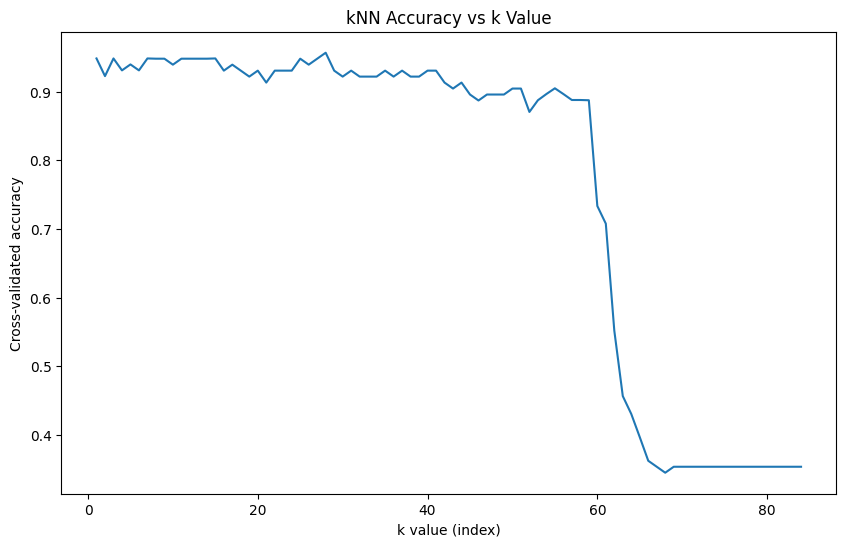

In [30]:
################################################
# BLOCK 29:  USING CROSS VALIDATION
################################################

#
# to do this, we use "cross validation"
# (see slide 45)
#

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

#
# cross-validation splits the training set into two pieces:
#   + model-building and model-validation. We'll use "build" and "validate"
#

max_k = 85
all_accuracies = []
best_k = 1
best_accuracy = -1

for k in range(1, max_k, 1):
    knn_cv_model = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn_cv_model, X_train, y_train, cv=5)
    this_cv_accuracy = cv_scores.mean()
    print(f"k: {k:2d}  cv accuracy: {this_cv_accuracy:7.4f}")
    all_accuracies.append(this_cv_accuracy)
    if this_cv_accuracy > best_accuracy:
        best_accuracy = this_cv_accuracy
        best_k = k
# assign best value of k to best_k
#best_k = k      # *** AT THE MOMENT THIS IS INCORRECT ***
# you'll need to modify the loop above to find and remember the real best_k

print(f"best_k = {best_k}   yields the highest average cv accuracy.")  # print the best one

plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1,len(all_accuracies)+1), y=all_accuracies)
plt.xlabel("k value (index)")
plt.ylabel("Cross-validated accuracy")
plt.title("kNN Accuracy vs k Value")
plt.show()

In [31]:
################################################
# BLOCK 30:  RE-BUILD & RE-TRAIN USING BEST k
################################################

#
# Now, we re-create and re-run the  "Model-building and -training Cell"
#
# Now, using best_k instead of the original, randomly-guessed value    How does it do?!
#
from sklearn.neighbors import KNeighborsClassifier
knn_model_tuned = KNeighborsClassifier(n_neighbors = best_k)   # here, we use the best_k

# we train the model (one line!)
knn_model_tuned.fit(X_train, y_train)                              # yay!  trained!
print(f"Created + trained a knn classifier, now tuned with a (best) k of {best_k}")

Created + trained a knn classifier, now tuned with a (best) k of 28


In [32]:
################################################
# BLOCK 31:  RE-TEST THE BEST-k MODEL
################################################

#
# Re-create and re-run the  "Model-testing Cell"     How does it do with best_k?!
#
predicted_labels = knn_model_tuned.predict(X_test)
actual_labels = y_test

# Let's print them so we can compare...
print("Predicted labels:", predicted_labels)
print("Actual labels:", actual_labels)
print()
# and, we'll print our nicer table...
compareLabels(predicted_labels,actual_labels)

Predicted labels: [1. 1. 1. 1. 1. 0. 1. 2. 2. 2. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 2. 2. 1. 2.
 2. 0. 2. 1. 2.]
Actual labels: [1. 1. 1. 1. 2. 0. 1. 2. 2. 2. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 2. 2. 1. 2.
 2. 0. 2. 1. 2.]

row   0 :   versicolor versicolor     
row   1 :   versicolor versicolor     
row   2 :   versicolor versicolor     
row   3 :   versicolor versicolor     
row   4 :   versicolor virginica      incorrect
row   5 :       setosa setosa         
row   6 :   versicolor versicolor     
row   7 :    virginica virginica      
row   8 :    virginica virginica      
row   9 :    virginica virginica      
row  10 :       setosa setosa         
row  11 :       setosa setosa         
row  12 :       setosa setosa         
row  13 :       setosa setosa         
row  14 :       setosa setosa         
row  15 :   versicolor versicolor     
row  16 :       setosa setosa         
row  17 :       setosa setosa         
row  18 :   versicolor versicolor     
row  19 :       setosa setosa       

28

In [33]:
################################################
# BLOCK 32:  TRYING DIFFERENT PERMUTATIONS
################################################

#
# Before moving on, go back and choose a new permutation to give
# new testing and training sets, and go back through the steps
# for identifying the "best" k (starting at Block 22 and re-doing
# up through Block 31).
#
# Repeat this several times.
# Do you get the same value for k each time?  Why or why not?
#

In [34]:
####################################################
# BLOCK 33:  REBUILD & TRAIN USING BEST k & ALL DATA
####################################################

# Ok!  Now we have tuned knn to use the "best" value of k...
#
# And, we should really use ALL available data to train our final predictive model
# (not split into test and train as before)
#

knn_model_final = KNeighborsClassifier(n_neighbors=best_k)   # here, we use the best_k
knn_model_final.fit(X_all, y_all)                            # yay!  trained!
print(f"Created + trained a 'final' knn classifier, with a (best) k of {best_k}")

Created + trained a 'final' knn classifier, with a (best) k of 28


In [35]:
####################################################
# BLOCK 34:  TRYING FINAL MODEL "IN THE WILD"
####################################################

#
# final predictive model (k-nearest-neighbor), with tuned k + ALL data incorporated
#

def predictiveModel( features: list[float] ) -> None:
    ''' input: a list of four features
                [ sepallen, sepalwid, petallen, petalwid ]
        output: the predicted species of iris, from
                  setosa (0), versicolor (1), virginica (2)
    '''
    our_features = np.asarray([features])                 # extra brackets needed
    predicted_species = knn_model_final.predict(our_features)

    predicted_species = int(round(predicted_species[0]))  # unpack one element
    name = species_names[predicted_species]
    return f"{name} ({predicted_species})"

#
# Try it on several!
#
# features = eval(input("Enter new features: "))
#
features = [6.7,3.3,5.7,2.1]  # [5.8,2.7,4.1,1.0] [4.6,3.6,3.0,2.2] [6.7,3.3,5.7,2.1]
result = predictiveModel( features )
print(f"I predict {result} from features {features}")

I predict virginica (2) from features [6.7, 3.3, 5.7, 2.1]


In [36]:
################################################################
# BLOCK 35a:  HOW DOES THE MODEL PERFORM ON MEAN OF EACH FLOWER?
################################################################

# let's recall the species names and their order in the list
print(species_names)
print('=' * 70)

# and let's recall what the final DataFrame looks like, noting that
# the irisname was converted to the corresponding index in species_names
print(df_final)

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str
     sepallen  sepalwid  petallen  petalwid  irisname
1         4.9       3.0       1.4       0.2         0
2         4.7       3.2       1.3       0.2         0
3         4.6       3.1       1.5       0.2         0
4         5.0       3.6       1.4       0.2         0
..        ...       ...       ...       ...       ...
144       6.7       3.3       5.7       2.5         2
145       6.7       3.0       5.2       2.3         2
146       6.3       2.5       5.0       1.9         2
147       6.5       3.0       5.2       2.0         2

[145 rows x 5 columns]


In [37]:
################################################################
# BLOCK 35b:  HOW DOES THE MODEL PERFORM ON MEAN OF EACH FLOWER?
################################################################

# let's grab the data from df_final corresponding to versicolor
versicolor_data = df_final[ df_final['irisname'] == convertSpecies('versicolor') ]
print(versicolor_data)
print('=' * 70)

# let's print the mean of each column
print(versicolor_data.mean())
print('=' * 70)

# and let's grab the features means only (don't need the label) for versicolor
versicolor_features_means = np.asarray(versicolor_data.mean()[:-1])
print(versicolor_features_means)

# now run the predictive model (see Block 34 above) and print a corresponding
# message

# >>> YOU ADD CODE HERE
result = predictiveModel(versicolor_features_means)
print(f"Mean versicolor features {versicolor_features_means} -> {result}")

    sepallen  sepalwid  petallen  petalwid  irisname
50       7.0       3.2       4.7       1.4         1
51       6.4       3.2       4.5       1.5         1
52       6.9       3.1       4.9       1.5         1
53       5.5       2.3       4.0       1.3         1
..       ...       ...       ...       ...       ...
96       5.7       2.9       4.2       1.3         1
97       6.2       2.9       4.3       1.3         1
98       5.1       2.5       3.0       1.1         1
99       5.7       2.8       4.1       1.3         1

[50 rows x 5 columns]
sepallen    5.936
sepalwid    2.770
petallen    4.260
petalwid    1.326
irisname    1.000
dtype: float64
[5.936 2.77  4.26  1.326]
Mean versicolor features [5.936 2.77  4.26  1.326] -> versicolor (1)


In [38]:
################################################################
# BLOCK 35c:  HOW DOES THE MODEL PERFORM ON MEAN OF EACH FLOWER?
################################################################

# Automate the process used in Block 35b, across all species:
#
# Loop across species names, and for each species,
#   (a) pull that corresponding data from df_final
#   (b) compute the means of the features, storing as a numpy array
#   (c) call the predictive model using those features
#   (d) print a corresponding message

# >> YOU ADD CODE HERE -- YOU SHOULD NEED NO MORE THAN 5 LINES OF CODE
for name in species_names:
    species_data = df_final[df_final['irisname'] == convertSpecies(name)]
    species_features_means = np.asarray(species_data.mean()[:-1])
    result = predictiveModel(species_features_means)
    print(f"Mean {name} features {species_features_means} -> {result}")

Mean setosa features [5.00425532 3.43617021 1.45957447 0.24893617] -> setosa (0)
Mean versicolor features [5.936 2.77  4.26  1.326] -> versicolor (1)
Mean virginica features [6.61041667 2.96458333 5.56458333 2.025     ] -> virginica (2)
